# Synchrony analysis: kappa=0 (no lateral coupling) ablation model

Same four-part analysis as `08_synchrony_kuramoto_hebbian.ipynb`
(identical architecture/hyperparameters otherwise: lr=1e-3, n_osc=50,
v_hidden=32, readout_hidden=32, pad_pre=pad_post=20), but with the
Kuramoto coupling term (`kappa`) set to **0** -- the two hemispheres'
oscillator populations are never pulled toward each other. Best
checkpoint: epoch 157, val loss 0.000021 (vs. 0.0000118 for the coupled
kappa=0.5 model -- coupling helps prediction accuracy by ~1.8x).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

K0_DIR = Path.cwd().parent / "outputs_v4_kappa0"
data = np.load(K0_DIR / "best_oscillator_states.npz", allow_pickle=True)

def _cast(arr, dtype):
    return [np.asarray(x, dtype=dtype) for x in arr]

phi_L_all = _cast(data["phi_L"], np.float64); phi_R_all = _cast(data["phi_R"], np.float64)
r_L_all = _cast(data["r_L"], np.float64); r_R_all = _cast(data["r_R"], np.float64)
z_real_L_all = _cast(data["z_real_L"], np.float64); z_imag_L_all = _cast(data["z_imag_L"], np.float64)
traj_gt_all = _cast(data["traj_gt"], np.float64)
moving_all = _cast(data["moving_flag"], np.float64)

n_trials = len(phi_L_all)
print(f"{n_trials} validation trials, T={phi_L_all[0].shape[0]}, N={phi_L_all[0].shape[1]} oscillators/side")
print(f"rest steps (pre+post): {int((moving_all[0]==0).sum())}, motion steps: {int((moving_all[0]==1).sum())}")

100 validation trials, T=139, N=50 oscillators/side
rest steps (pre+post): 39, motion steps: 100


## Part A: Kuramoto order parameter

In [2]:
def kuramoto_R(phi):
    return np.abs(np.mean(np.exp(1j * phi), axis=1))

def two_population_R(phi_L, phi_R):
    psi_L = np.angle(np.mean(np.exp(1j * phi_L), axis=1))
    psi_R = np.angle(np.mean(np.exp(1j * phi_R), axis=1))
    return np.abs((np.exp(1j * psi_L) + np.exp(1j * psi_R)) / 2)

R_L_all, R_R_all, R_LR_all = [], [], []
for i in range(n_trials):
    R_L_all.append(kuramoto_R(phi_L_all[i]))
    R_R_all.append(kuramoto_R(phi_R_all[i]))
    R_LR_all.append(two_population_R(phi_L_all[i], phi_R_all[i]))

rest_L, motion_L, rest_R, motion_R, rest_LR, motion_LR = [], [], [], [], [], []
for i in range(n_trials):
    rest_mask = moving_all[i] == 0; move_mask = moving_all[i] == 1
    rest_L.append(R_L_all[i][rest_mask].mean()); motion_L.append(R_L_all[i][move_mask].mean())
    rest_R.append(R_R_all[i][rest_mask].mean()); motion_R.append(R_R_all[i][move_mask].mean())
    rest_LR.append(R_LR_all[i][rest_mask].mean()); motion_LR.append(R_LR_all[i][move_mask].mean())

rest_L, motion_L = np.array(rest_L), np.array(motion_L)
rest_R, motion_R = np.array(rest_R), np.array(motion_R)
rest_LR, motion_LR = np.array(rest_LR), np.array(motion_LR)

for name, rest, motion in [("L (intra)", rest_L, motion_L), ("R (intra)", rest_R, motion_R), ("L-R (inter)", rest_LR, motion_LR)]:
    pct = 100 * (rest.mean() - motion.mean()) / rest.mean()
    t, p = stats.ttest_rel(rest, motion)
    print(f"{name:12s}: rest R={rest.mean():.4f}  motion R={motion.mean():.4f}  desync={pct:+.1f}%  t={t:.2f} p={p:.2e}")

L (intra)   : rest R=0.4457  motion R=0.1626  desync=+63.5%  t=232.09 p=2.81e-137
R (intra)   : rest R=0.4648  motion R=0.1801  desync=+61.2%  t=201.72 p=2.92e-131
L-R (inter) : rest R=0.8686  motion R=0.9418  desync=-8.4%  t=-9.24 p=5.01e-15


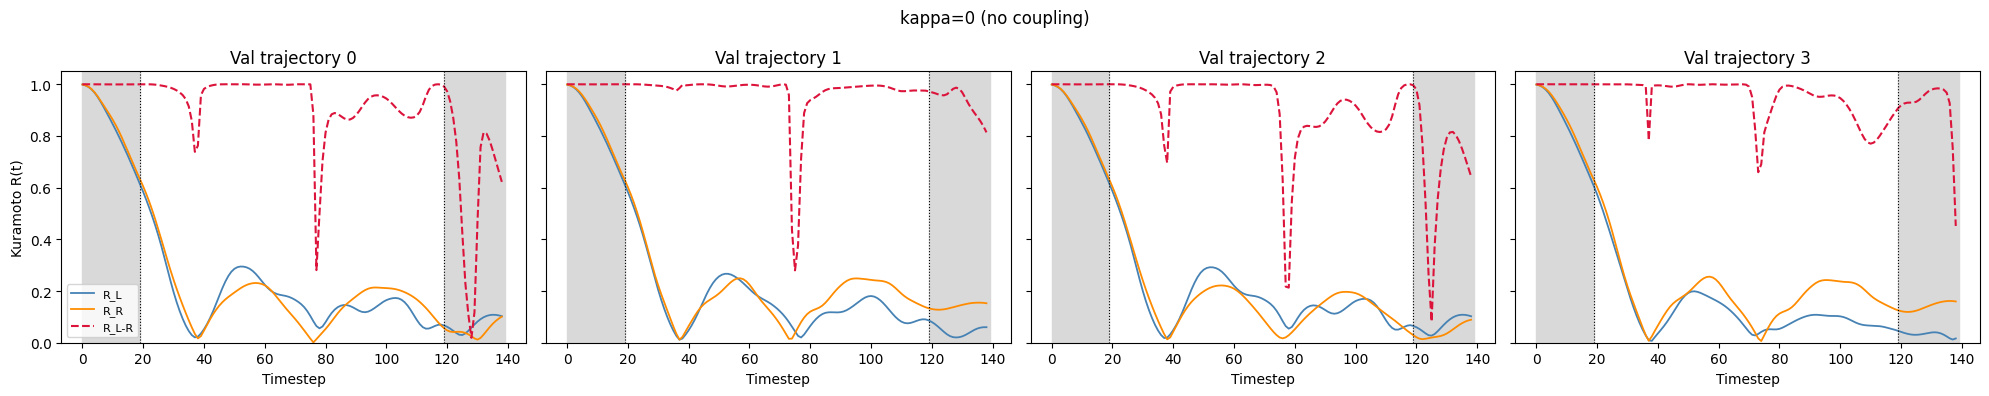

In [3]:
n_show = 4
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4), sharey=True)
for col, i in enumerate(range(n_show)):
    ax = axes[col]
    mflag = moving_all[i]; T = len(mflag)
    move_start = int(np.argmax(mflag == 1)); move_end = T - int(np.argmax(mflag[::-1] == 1))
    ax.axvspan(0, move_start, color="0.85", zorder=0); ax.axvspan(move_end, T, color="0.85", zorder=0)
    ax.plot(R_L_all[i], color="steelblue", lw=1.3, label="R_L")
    ax.plot(R_R_all[i], color="darkorange", lw=1.3, label="R_R")
    ax.plot(R_LR_all[i], color="crimson", lw=1.5, ls="--", label="R_L-R")
    ax.axvline(move_start, color="black", lw=0.8, ls=":"); ax.axvline(move_end, color="black", lw=0.8, ls=":")
    ax.set_title(f"Val trajectory {i}"); ax.set_xlabel("Timestep"); ax.set_ylim(0, 1.05)
    if col == 0:
        ax.set_ylabel("Kuramoto R(t)"); ax.legend(fontsize=8)
plt.suptitle("kappa=0 (no coupling)")
plt.tight_layout()
plt.savefig(K0_DIR / "kuramoto_timeseries.png", dpi=130, bbox_inches="tight")
plt.show()

## Part B: Hebbian synchrony detector (amplitude-normalized, not frequency-normalized -- see notebook 08 for why)

In [4]:
def freq_normalize(z):
    return z / np.abs(z)

def train_hebbian(Z_train, eta=0.001, iterations=200, seed=0):
    rng = np.random.default_rng(seed)
    N = Z_train.shape[1]
    w = rng.uniform(-1, 1, (N, 1)) + 1j * rng.uniform(-1, 1, (N, 1))
    w = w / np.linalg.norm(w)
    for _ in range(iterations):
        P_t = Z_train @ np.conj(w)
        w = w + eta * (Z_train.T @ np.conj(P_t))
        w = w / np.linalg.norm(w)
    return w

def project(Z_full, w):
    return np.abs(Z_full @ np.conj(w)).flatten()

n_stats = 30
hebbian_rest_means, hebbian_motion_means = [], []
for i in range(n_stats):
    z_L = z_real_L_all[i] + 1j * z_imag_L_all[i]
    z_af = freq_normalize(z_L)
    rest_mask = moving_all[i] == 0; move_mask = moving_all[i] == 1
    w = train_hebbian(z_af[rest_mask], eta=0.001, iterations=200)
    P_full = project(z_af, w)
    hebbian_rest_means.append(P_full[rest_mask].mean())
    hebbian_motion_means.append(P_full[move_mask].mean())

hebbian_rest_means, hebbian_motion_means = np.array(hebbian_rest_means), np.array(hebbian_motion_means)
pct = 100 * (hebbian_rest_means.mean() - hebbian_motion_means.mean()) / hebbian_rest_means.mean()
t, p = stats.ttest_rel(hebbian_rest_means, hebbian_motion_means)
print(f"Hebbian |P|: rest={hebbian_rest_means.mean():.4f}  motion={hebbian_motion_means.mean():.4f}  "
      f"drop={pct:+.1f}%  t={t:.2f} (n={n_stats}) p={p:.2e}  [ceiling=sqrt(50)={np.sqrt(50):.3f}]")

Hebbian |P|: rest=4.7999  motion=2.0439  drop=+57.4%  t=55.33 (n=30) p=5.88e-31  [ceiling=sqrt(50)=7.071]


## Part C: mu-band power (ERD/ERS)

In [5]:
pre_L, post_L, motion_L_pow, pre_R, post_R, motion_R_pow = [], [], [], [], [], []
for i in range(n_trials):
    mflag = moving_all[i]; T = len(mflag)
    move_start = int(np.argmax(mflag == 1)); move_end = T - int(np.argmax(mflag[::-1] == 1))
    pre_L.append((r_L_all[i][1:move_start] ** 2).mean()); post_L.append((r_L_all[i][move_end:] ** 2).mean())
    motion_L_pow.append((r_L_all[i][move_start:move_end] ** 2).mean())
    pre_R.append((r_R_all[i][1:move_start] ** 2).mean()); post_R.append((r_R_all[i][move_end:] ** 2).mean())
    motion_R_pow.append((r_R_all[i][move_start:move_end] ** 2).mean())

for side, pre, motion, post in [("L", pre_L, motion_L_pow, post_L), ("R", pre_R, motion_R_pow, post_R)]:
    pre, motion, post = np.array(pre), np.array(motion), np.array(post)
    erd = 100 * (pre.mean() - motion.mean()) / pre.mean()
    ers = 100 * (post.mean() - motion.mean()) / pre.mean()
    t1, p1 = stats.ttest_rel(pre, motion); t2, p2 = stats.ttest_rel(motion, post)
    print(f"{side}: pre={pre.mean():.4f}  motion={motion.mean():.4f}  post={post.mean():.4f}  "
          f"ERD={erd:+.1f}% (p={p1:.1e})  ERS={ers:+.1f}% (p={p2:.1e})")

L: pre=1.0009  motion=0.9894  post=0.9826  ERD=+1.1% (p=1.4e-16)  ERS=-0.7% (p=1.4e-15)
R: pre=1.0177  motion=0.9702  post=0.9327  ERD=+4.7% (p=1.6e-60)  ERS=-3.7% (p=1.6e-34)


## Part D: hemisphere-specific (contralateral-style) lateralization

n left-active=42, n right-active=58

KURAMOTO R (active vs inactive side):
  left-active:  R(active,L)=0.1419  R(inactive,R)=0.1937  diff=-0.0517  t=-29.48 p=3.17e-29
  right-active: R(active,R)=0.1703  R(inactive,L)=0.1776  diff=-0.0073  t=-6.11 p=9.48e-08

MU-POWER (active vs inactive side):
  left-active:  pow(active,L)=1.0004  pow(inactive,R)=0.9609  diff=+0.0395  t=66.52 p=2.15e-43
  right-active: pow(active,R)=0.9770  pow(inactive,L)=0.9814  diff=-0.0044  t=-10.22 p=1.68e-14


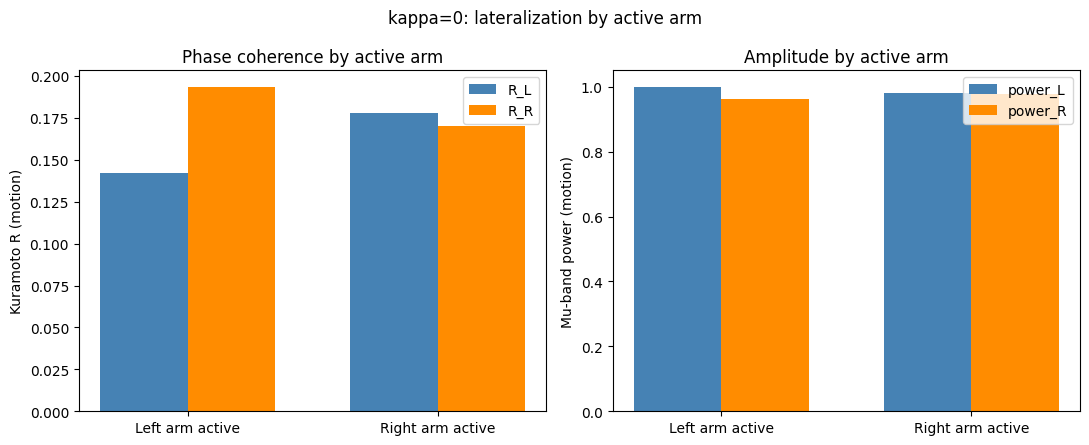

In [6]:
la_RL, la_RR, ra_RL, ra_RR = [], [], [], []
la_pL, la_pR, ra_pL, ra_pR = [], [], [], []

for i in range(n_trials):
    traj = traj_gt_all[i]
    left_active = np.linalg.norm(traj[-1,:2]-traj[0,:2]) > np.linalg.norm(traj[-1,2:]-traj[0,2:])
    move_mask = moving_all[i] == 1
    R_L = kuramoto_R(phi_L_all[i])[move_mask].mean(); R_R = kuramoto_R(phi_R_all[i])[move_mask].mean()
    pow_L = (r_L_all[i][move_mask]**2).mean(); pow_R = (r_R_all[i][move_mask]**2).mean()
    if left_active:
        la_RL.append(R_L); la_RR.append(R_R); la_pL.append(pow_L); la_pR.append(pow_R)
    else:
        ra_RL.append(R_L); ra_RR.append(R_R); ra_pL.append(pow_L); ra_pR.append(pow_R)

print(f"n left-active={len(la_RL)}, n right-active={len(ra_RL)}\n")
la_RL,la_RR,ra_RL,ra_RR = map(np.array,(la_RL,la_RR,ra_RL,ra_RR))
la_pL,la_pR,ra_pL,ra_pR = map(np.array,(la_pL,la_pR,ra_pL,ra_pR))

print("KURAMOTO R (active vs inactive side):")
t,p = stats.ttest_rel(la_RL, la_RR)
print(f"  left-active:  R(active,L)={la_RL.mean():.4f}  R(inactive,R)={la_RR.mean():.4f}  diff={la_RL.mean()-la_RR.mean():+.4f}  t={t:.2f} p={p:.2e}")
t,p = stats.ttest_rel(ra_RR, ra_RL)
print(f"  right-active: R(active,R)={ra_RR.mean():.4f}  R(inactive,L)={ra_RL.mean():.4f}  diff={ra_RR.mean()-ra_RL.mean():+.4f}  t={t:.2f} p={p:.2e}")

print("\nMU-POWER (active vs inactive side):")
t,p = stats.ttest_rel(la_pL, la_pR)
print(f"  left-active:  pow(active,L)={la_pL.mean():.4f}  pow(inactive,R)={la_pR.mean():.4f}  diff={la_pL.mean()-la_pR.mean():+.4f}  t={t:.2f} p={p:.2e}")
t,p = stats.ttest_rel(ra_pR, ra_pL)
print(f"  right-active: pow(active,R)={ra_pR.mean():.4f}  pow(inactive,L)={ra_pL.mean():.4f}  diff={ra_pR.mean()-ra_pL.mean():+.4f}  t={t:.2f} p={p:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(2); width = 0.35
axes[0].bar(x - width/2, [la_RL.mean(), ra_RL.mean()], width, label="R_L", color="steelblue")
axes[0].bar(x + width/2, [la_RR.mean(), ra_RR.mean()], width, label="R_R", color="darkorange")
axes[0].set_xticks(x); axes[0].set_xticklabels(["Left arm active", "Right arm active"])
axes[0].set_ylabel("Kuramoto R (motion)"); axes[0].set_title("Phase coherence by active arm"); axes[0].legend()
axes[1].bar(x - width/2, [la_pL.mean(), ra_pL.mean()], width, label="power_L", color="steelblue")
axes[1].bar(x + width/2, [la_pR.mean(), ra_pR.mean()], width, label="power_R", color="darkorange")
axes[1].set_xticks(x); axes[1].set_xticklabels(["Left arm active", "Right arm active"])
axes[1].set_ylabel("Mu-band power (motion)"); axes[1].set_title("Amplitude by active arm"); axes[1].legend()
plt.suptitle("kappa=0: lateralization by active arm")
plt.tight_layout()
plt.savefig(K0_DIR / "lateralization_by_active_arm.png", dpi=130, bbox_inches="tight")
plt.show()